In [37]:
%pip install matplotlib numpy
%config IPCompleter.greedy=True

Note: you may need to restart the kernel to use updated packages.


# Diffusione del calore
In questa esercitazione simuleremo la diffusione del calore in una sbarra di lunghezza $L$ i cui estremi sono tenuti a temperatura fissa. L'equazione che descrive la diffusione del calore $$\frac{\partial T}{\partial t}=\alpha \frac{\partial^2 T}{\partial x^2}$$ contiene sia derivate spaziali che derivate temporali, quindi per la sua risoluzione avremo bisogno di una condizione iniziale (Initial Value Problem), cioè della temperatura all'istante $t=0$, e di condizioni al contorno (Boundary Value Problem), cioè delle temperature agli estremi della sbarra.

La risoluzione di questo tipo di problemi si chiama **Forward Time Central Space** e prevede di calcolare la soluzione ad un passo temporale successivo (FT) utilizzando la differenza centrale (CS) del passo temporale precedente. Prima calcoliamo la differenza in avanti: $$\frac{\partial T}{\partial t}\approx\frac{T_{i}^{n+1}-T_{i}^{n}}{\Delta t},$$ e successivamente la differenza centrale: $$\frac{\partial^2 T}{\partial t^2}\approx\frac{T_{i+1}^{n} - 2T_{i}^{n} + T_{i-1}^{n}}{\Delta x^2},$$ dove l'indice $n$ indica la step temporale e l'indice $i$ quello spaziale.
Combinando questi risultati nell'equazione del calore otteniamo la **formula di aggiornamento** che implementeremo nell'algoritmo: $$T_{i}^{n+1} = T_{i}^{n} + r\cdot(T_{i+1}^{n} - 2T_{i}^{n} + T_{i-1}^{n}),$$ dove il parametro $r=\alpha\cdot\Delta t/\Delta x^2$ è importante per la stabilità del sistema (vedremo che per $r>0.5$ il sistema diventa instabile e la simulazione non offre più risultati accettabili).

In [38]:
import numpy as np 
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [10, 6.25]

In [39]:
L = 1
alpha = 0.01
Nx = 50
dx = L/Nx
dt_max = 0.02
r = 0.4
dt = r * dt_max
T0 = 1

In [40]:
def distribuzione_sin(T0: float, x: float, t: float, alpha: float, L: float) -> float:
    T_in = T0 * np.sin(np.pi * x / L)
    return T0 * np.exp(-alpha * np.pi**2 * t / L**2) * np.sin(np.pi * x / L)

xs = np.linspace(0, L, Nx+1)

Nell'implementazione dell'algoritmo calcoliamo $r$ utilizzando i passi spaziali e temporali in modo tale da evitare di utilizzare un valore di $r$ maggiore di $0.5$ ed entrare in regime di instabilità.
Utilizziamo come condizione iniziale una distribuzione di calore sinusoidale e teniamo gli estremi a temperatura $T(0,t)=T(L,t)=0°C$. 

Nell'algoritmo viene implementata una matrice le cui righe rappresentano i tempi e le colonne rappresentano lo spazio: in questo modo abbiamo il primo e l'ultimo elemento di ogni riga che rappresentano gli estremi della sbarra.

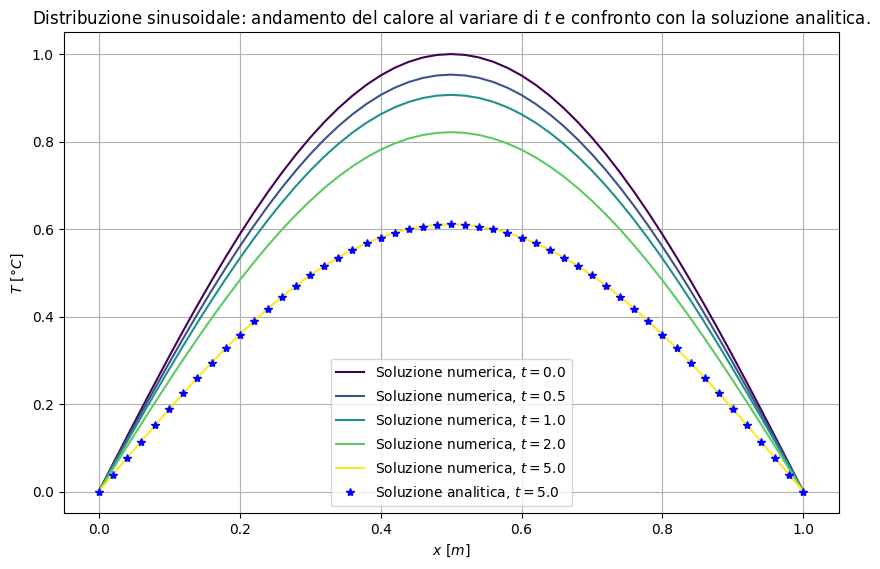

In [56]:
def ftcs(T0: float, Tl: float, Tr: float, x: list[float], t: float, dt: float, L: float, alpha: float, dx: float) -> list[float]:
    r = alpha * dt / (dx**2)
    steps = t / dt
    Ts = np.zeros((int(steps), len(x)))
    Ts[0,:] = T0 * np.sin(np.pi * x / L)
    Ts[:, 0], Ts[:, -1] = Tl, Tr
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
    return Ts

Ts = ftcs(T0=1, Tl=0, Tr=0, x=xs, t=5, dt=dt, L=L, alpha=alpha, dx=dx)
distr_sin = distribuzione_sin(T0=T0, x=xs, t=5, alpha=alpha, L=L)
cmap = plt.cm.viridis
times = [0.0, 0.5, 1.0, 2.0, 5.0]

for idx, t in enumerate(times):
    riga = int(t/dt)
    colore = cmap(idx / (len(times) - 1))
    if riga == 0:
        plt.plot(xs, Ts[riga, :], label=rf"Soluzione numerica, $t={t}$", color=colore)
    else:
        plt.plot(xs, Ts[riga-1, :], label=rf"Soluzione numerica, $t={t}$", color=colore)

plt.plot(xs, distr_sin, "*", label=r"Soluzione analitica, $t=5.0$", color="blue")
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$T\ [°C]$")
plt.title(r"Distribuzione sinusoidale: andamento del calore al variare di $t$ e confronto con la soluzione analitica.")
plt.grid()
plt.legend()
plt.show()

In [42]:
err_max_fin = np.max(np.abs(Ts[-1, :] - distr_sin))
print(err_max_fin)

0.0004624165953999171


La soluzione analitica è stata calcolata per $t=5\ s$ e notiamo che la soluzione numerica a $t=5\ s$ è sovrapponibile ad essa, infatti l'errore massimo fra le due soluzioni a $t=5\ s$ è pari a $\epsilon=0.0005\ °C$. Di seguito viene riportata una heatmap che mostra come il calore si diffonde nel tempo nella sbarra.

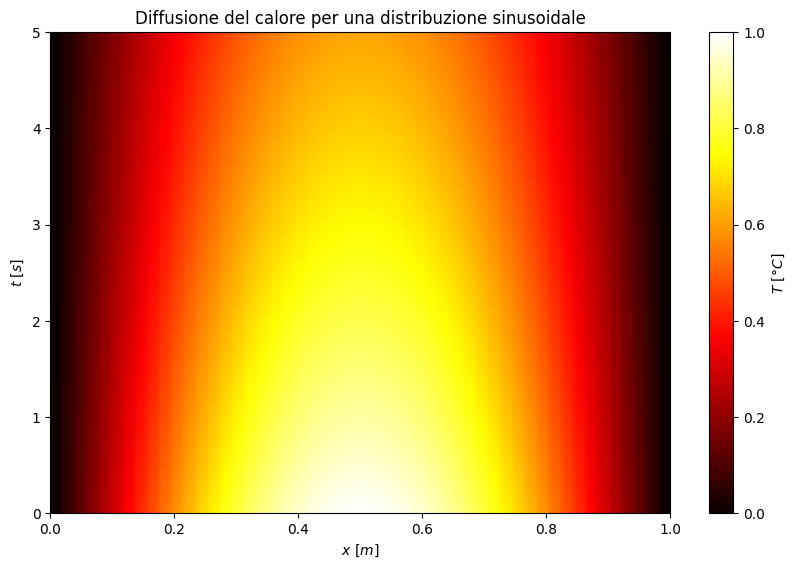

In [43]:
extent = [0, L, 0, len(Ts)*dt]
plt.imshow(Ts, extent=extent, aspect="auto", origin="lower", cmap="hot")
cbar = plt.colorbar()
cbar.set_label(r"$T\ [°C]$")
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$t\ [s]$")
plt.title("Diffusione del calore per una distribuzione sinusoidale")
plt.show()

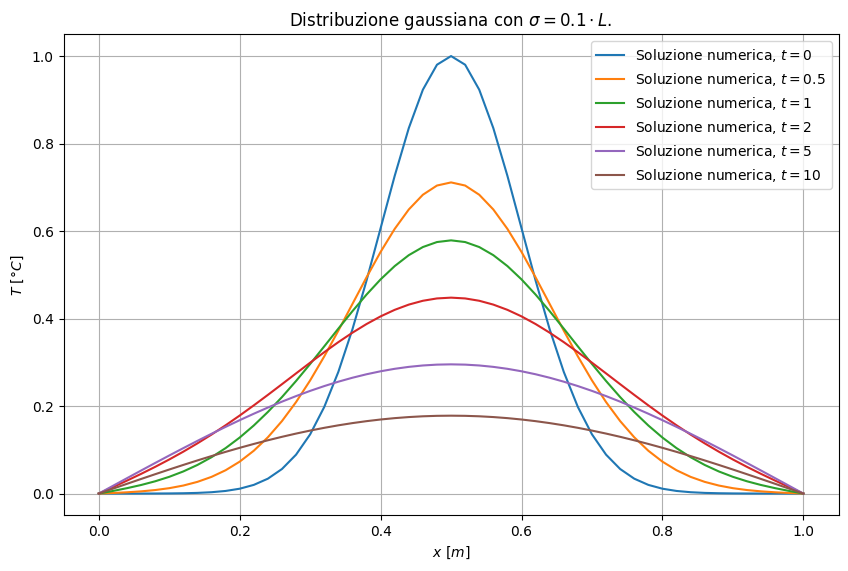

In [59]:
def ftcs1(T0: float, Tl: float, Tr: float, x: list[float], t: float, dt: float, L: float, alpha: float, dx: float) -> list[float]:
    r = alpha * dt / (dx**2)
    sigma = 0.1 * L
    steps = t / dt
    Ts = np.ones((int(steps), len(x)))
    Ts[0] = T0 * np.exp(-(x - L/2)**2 / (2 * sigma**2))
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
        Ts[i+1][0], Ts[i+1][-1] = Tl, Tr
    return Ts

Ts1 = ftcs1(T0=1, Tl=0, Tr=0, x=xs, t=10, dt=dt, L=L, alpha=alpha, dx=dx)

for i in [0, 0.5, 1, 2, 5, 10]:
    riga = int(i/dt)
    if riga == 0:
        plt.plot(xs, Ts1[riga, :], label=rf"Soluzione numerica, $t={i}$")
    else:
        plt.plot(xs, Ts1[riga-1, :], label=rf"Soluzione numerica, $t={i}$")

plt.grid()
plt.legend()
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$T\ [°C]$")
plt.title(r"Distribuzione gaussiana con $\sigma=0.1\cdot L$.")
plt.show()

Simulando una distribuzione gaussiana con $\sigma=0.1\cdot L$ è come se avessimo un picco di temperatura posto a $L/2$. Visualizzando l'andamento del profilo di temperatura a diversi istanti di tempo, con $t_{max}=10\ s$, notiamo che la gaussiana tende ad allargarsi mentre il suo massimo diminuisce.
Nella heatmap che segue possiamo vedere come il calore si distribuisce nella sbarra al variare del tempo. Nel grafico in cui viene mostrato l'andamento della temperatura in funzione del tempo notiamo che, dopo un picco iniziale, c'è una diminuzione molto rapida, quindi il calore si diffonde molto velocemente nel resto della sbarra portando ad un abbassamento repentino della temperatura.

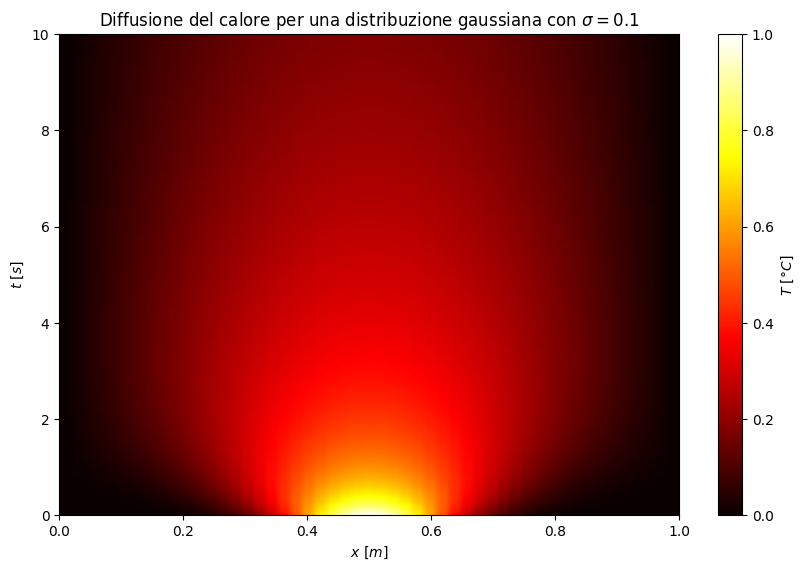

In [45]:
extent1 = [0, L, 0, len(Ts1)*dt]
plt.imshow(Ts1, extent=extent1, aspect="auto", origin="lower", cmap="hot")
cbar = plt.colorbar()
cbar.set_label(r"$T\ [°C]$")
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$t\ [s]$")
plt.title(r"Diffusione del calore per una distribuzione gaussiana con $\sigma=0.1$")
plt.show()

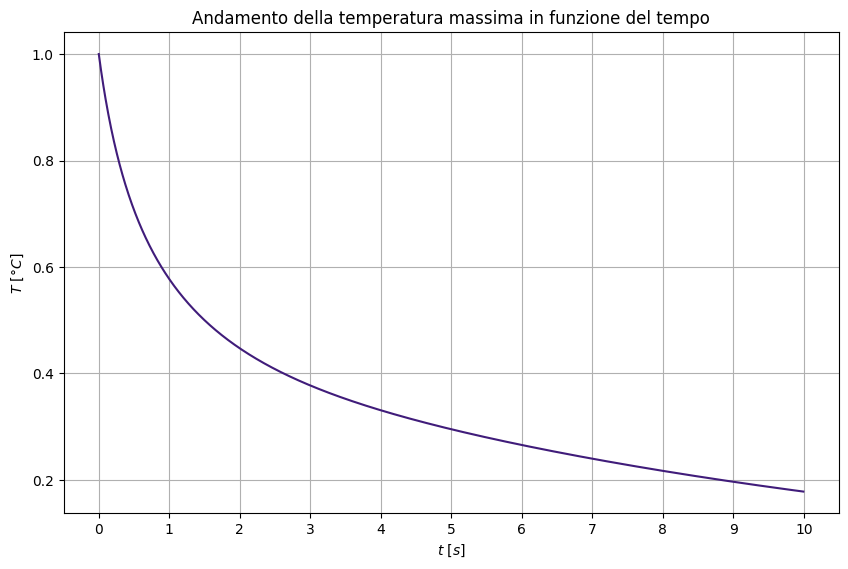

In [52]:
ts_max = []
for tst in Ts1:
    ts_max.append(max(tst))

time_ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
index_ticks = [t / dt for t in time_ticks]


plt.plot(ts_max, color="#401c7a")
plt.grid()
plt.xticks(index_ticks, time_ticks)
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$T\ [°C]$")
plt.title("Andamento della temperatura massima in funzione del tempo")
plt.show()

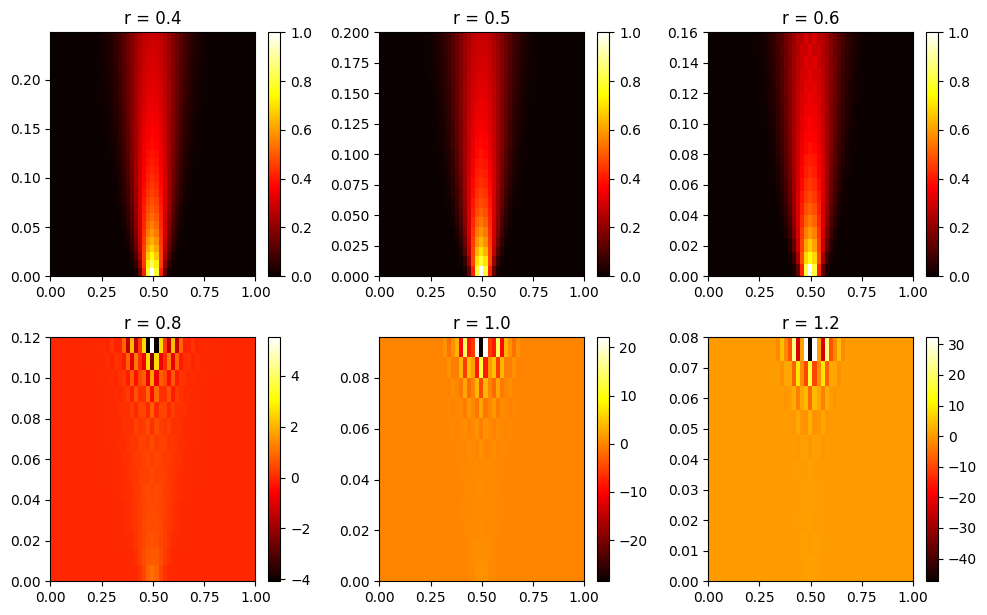

In [47]:
def ftcs2(T0: float, Tl: float, Tr: float, x: list[float], t: float, r: float, L: float, dx: float, alpha: float) -> list[float]:
    sigma = 0.03 * L
    dt = dx**2 * r / alpha
    steps = t / dt
    Ts = np.ones((int(steps), len(x)))
    Ts[0] = T0 * np.exp(-(x - L/2)**2 / (2 * sigma**2))
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
        Ts[i+1][0], Ts[i+1][-1] = Tl, Tr
    return Ts

fig, axes = plt.subplots(2, 3)

r_values = [0.4, 0.5, 0.6, 0.8, 1.0, 1.2]
axes_flat = axes.flatten()

for i, r_val in enumerate(r_values):
    data = ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=r_val, L=L, dx=dx, alpha=alpha)
    ext = [0, L, 0, len(data)*dt]
    im = axes_flat[i].imshow(data, extent=ext, aspect="auto", origin="lower", cmap="hot")
    axes_flat[i].set_title(f"r = {r_val}")
    fig.colorbar(im, ax=axes_flat[i])

plt.tight_layout()
plt.show()

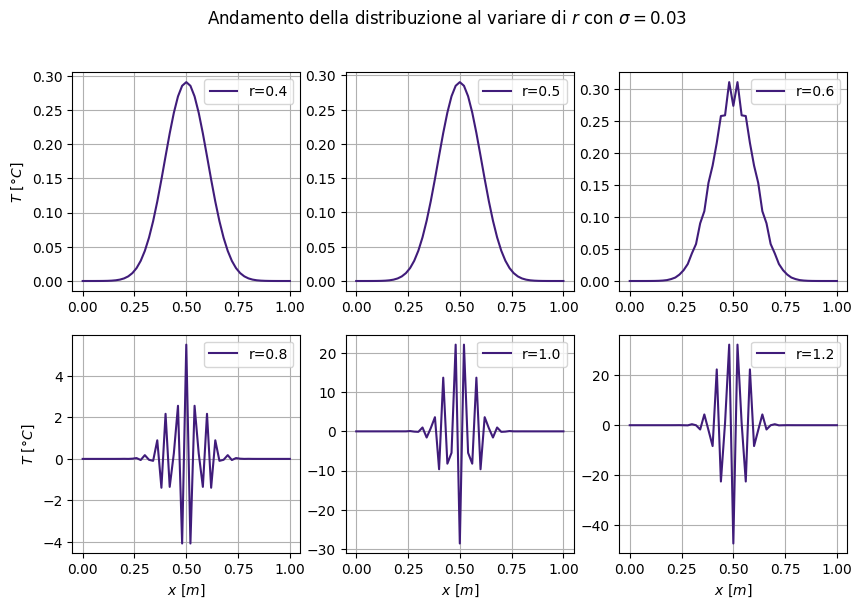

In [53]:
fig, axes = plt.subplots(2, 3)

axes[0,0].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.4, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.4", color="#401c7a")
axes[0,0].grid(True)
axes[0,0].set_ylabel(r"$T\ [°C]$")
axes[0,0].legend()

axes[0,1].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.5, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.5", color="#401c7a")
axes[0,1].grid(True)
axes[0,1].legend()

axes[0,2].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.6, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.6", color="#401c7a")
axes[0,2].grid(True)
axes[0,2].legend()

axes[1,0].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=0.8, L=L, dx=dx, alpha=alpha)[-1, :], label="r=0.8", color="#401c7a")
axes[1,0].grid(True)
axes[1,0].set_xlabel(r"$x\ [m]$")
axes[1,0].set_ylabel(r"$T\ [°C]$")
axes[1,0].legend()

axes[1,1].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=1.0, L=L, dx=dx, alpha=alpha)[-1, :], label="r=1.0", color="#401c7a")
axes[1,1].grid(True)
axes[1,1].set_xlabel(r"$x\ [m]$")
axes[1,1].legend()

axes[1,2].plot(xs, ftcs2(T0=T0, Tl=0, Tr=0, x=xs, t=0.5, r=1.2, L=L, dx=dx, alpha=alpha)[-1, :], label="r=1.2", color="#401c7a")
axes[1,2].grid(True)
axes[1,2].set_xlabel(r"$x\ [m]$")
axes[1,2].legend()

plt.suptitle(r"Andamento della distribuzione al variare di $r$ con $\sigma=0.03$")
plt.show()

Dopo aver posto $\sigma=0.03\cdot L$, abbiamo fatto variare il fattore $r$ in un range che va da $0.4$ a $1.2$ per analizzare la stabilità del sistema. È immediato notare che superando $r=0.5$, e in particolare per $r=0.8$, il sistema non fornisce più risultati accettabili perché compaiono oscillazioni che fanno divergere la simulazione molto velocemente. Questo fenomeno è ancora più accentuato dalle heatmap: per $r=0.8$ abbiamo un profilo di temperatura che non ha più senso fisico, infatti zone molto fredde (quadrati scuri) sono affiancate da zone molto calde (quadrati chiari). 

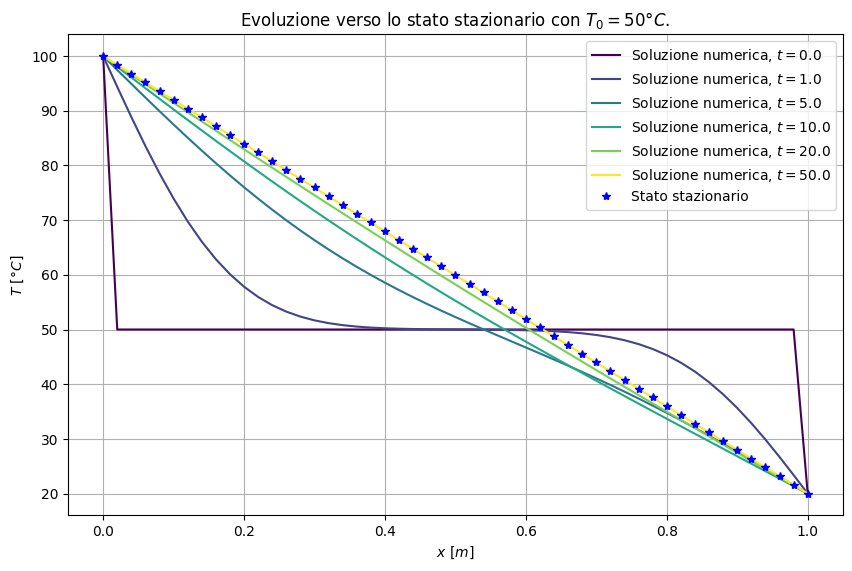

In [49]:
def ftcs3(T0: float, Tl: float, Tr: float, x: list[float], t: float, dt: float, L: float, alpha: float, dx: float) -> list[float]:
    r = alpha * dt / (dx**2)
    steps = t / dt
    Ts = np.zeros((int(steps), len(x)))
    Ts[0,:] = T0
    Ts[:, 0], Ts[:, -1] = Tl, Tr
    
    for i in range(int(steps)-1):
        for j in range(1, len(xs)-1):
            Ts[i+1][j] = Ts[i][j] + r * (Ts[i][j+1] - 2*Ts[i][j] + Ts[i][j-1])
    return Ts

Ts3 = ftcs3(T0=50, Tl=100, Tr=20, x=xs, t=50, dt=dt, L=L, alpha=alpha, dx=dx)
times = [0.0, 1.0, 5.0, 10.0, 20.0, 50.0]
cmap = plt.cm.viridis

for idx, t in enumerate(times):
    riga = int(t/dt)
    colore = cmap(idx / (len(times) - 1))
    if riga == 0:
        plt.plot(xs, Ts3[riga, :], label=rf"Soluzione numerica, $t={t}$", color=colore)
    else:
        plt.plot(xs, Ts3[riga-1, :], label=rf"Soluzione numerica, $t={t}$", color=colore)

plt.plot(xs, 100-80*xs, "*", label="Stato stazionario", color="blue", lw=0.8)
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$T\ [°C]$")
plt.legend()
plt.grid()
plt.title(r"Evoluzione verso lo stato stazionario con $T_0=50°C$.")
plt.show()

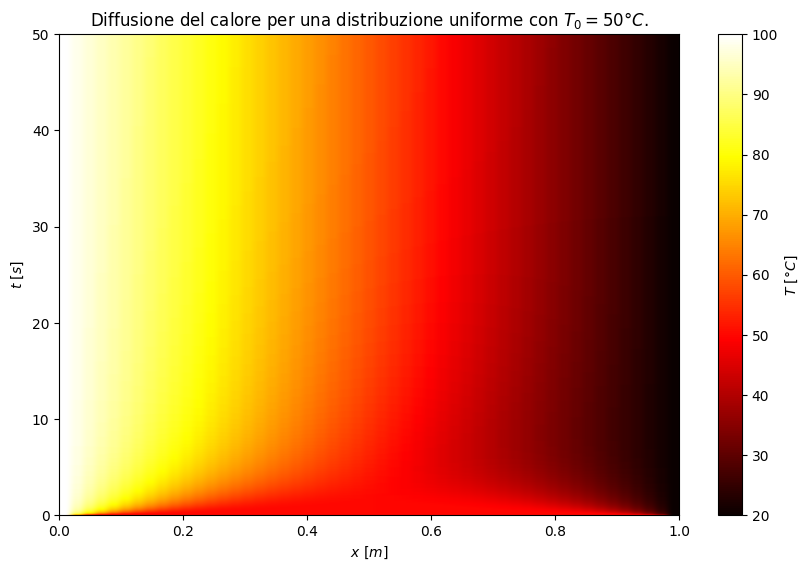

In [50]:
extent3 = [0, L, 0, len(Ts3)*dt]
plt.imshow(Ts3, extent=extent3, aspect="auto", origin="lower", cmap="hot")
cbar = plt.colorbar()
cbar.set_label(r"$T\ [°C]$")
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$t\ [s]$")
plt.title(r"Diffusione del calore per una distribuzione uniforme con $T_0=50°C$.")
plt.show()

0.09158234841342505


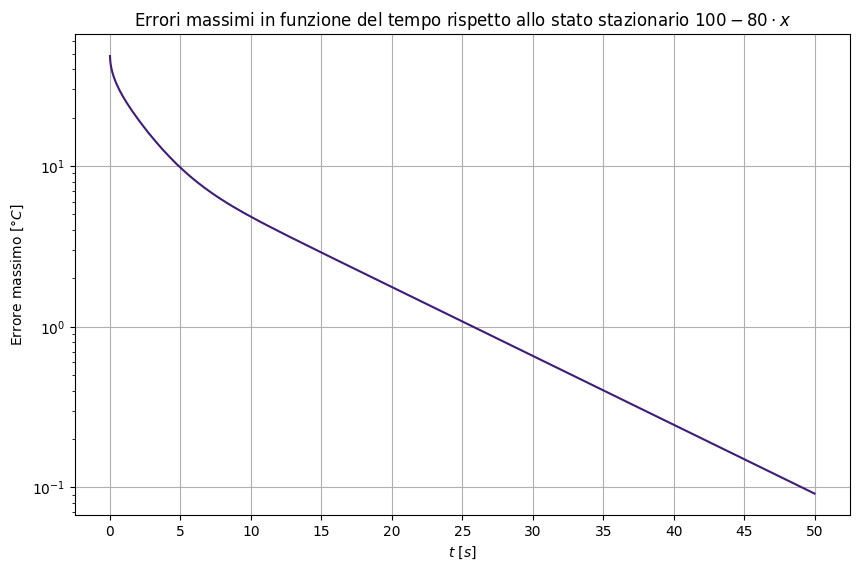

In [63]:
err_max = []
ref = 100 - 80*xs
for t in Ts3:
    err_max.append(np.max(np.abs(t-ref)))

print(err_max[-1])
time_ticks = np.arange(0, 51, 5)
index_ticks = [t / dt for t in time_ticks]
plt.plot(err_max, color="#401c7a")
plt.grid()
plt.xticks(index_ticks, time_ticks)
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"Errore massimo $[°C]$")
plt.yscale("log")
plt.title(r"Errori massimi in funzione del tempo rispetto allo stato stazionario $100 - 80\cdot x$")
plt.show()

Infine abbiamo analizzato l'evoluzione del sistema verso lo stato stazionario. Dopo aver aumentato il tempo di simulazione a $t=50\ s$ e aver imposto come condizioni al contorno $T(0,t)=100\ °C$ e $T(L,t)=20\ °C$, abbiamo confrontato la simulazione a diversi passi temporali con lo stato stazionario teorico dato dalla retta decrescente $100 - 80\cdot x$. 
Si nota che all'aumentare del tempo di simulazione anche la soluzione numerica tende a diventare una retta decrescente, andando infine a sovrapporsi alla previsione teorica, infatti il massimo errore fra la soluzione numerica e quella teorica a $t=50\ s$ è pari a $\epsilon=0.09\ °C$. 

Possiamo notare che dopo un transitorio pari a $t^*\approx5\ s$ l'andamento degli errori è lineare decrescente in scala semilogaritmica, quindi c'è una decrescita esponenziale verso lo stato stazionario.